# Agrupacion de casas en California

En este proyecto vamos a trabajar con el conjunto de datos de viviendas de California, construido a partir del censo de 1990. Cada fila representa un grupo de bloques censales, que es la unidad geografica mas pequena para la que el censo publica datos.

El objetivo es agrupar las viviendas segun su ubicacion geografica y el ingreso medio de la zona. Para eso vamos a combinar dos tipos de aprendizaje automatico:

1. Aprendizaje no supervisado (K-Means): agrupa los datos sin etiquetas previas.
2. Aprendizaje supervisado (clasificador): aprende a predecir el grupo usando esas etiquetas.

Este flujo es bastante comun en proyectos reales donde los datos no vienen etiquetados de antemano.

## Paso 1: Carga del conjunto de datos

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.cluster import KMeans
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import accuracy_score

import joblib
import os
import warnings
warnings.filterwarnings('ignore')

In [3]:
# Cargamos el dataset 
df = pd.read_csv("../data/raw/housing.csv")

print('Forma del dataset:', df.shape)
df.head()

Forma del dataset: (20640, 9)


,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422


In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 9 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   MedInc       20640 non-null  float64
 1   HouseAge     20640 non-null  float64
 2   AveRooms     20640 non-null  float64
 3   AveBedrms    20640 non-null  float64
 4   Population   20640 non-null  float64
 5   AveOccup     20640 non-null  float64
 6   Latitude     20640 non-null  float64
 7   Longitude    20640 non-null  float64
 8   MedHouseVal  20640 non-null  float64
dtypes: float64(9)
memory usage: 1.4 MB


In [5]:
# Comprobamos si hay valores nulos
print('Valores nulos por columna:')
print(df.isnull().sum())

Valores nulos por columna:
MedInc         0
HouseAge       0
AveRooms       0
AveBedrms      0
Population     0
AveOccup       0
Latitude       0
Longitude      0
MedHouseVal    0
dtype: int64


In [6]:
# Solo nos quedamos con las columnas que nos interesan
columnas = ['Latitude', 'Longitude', 'MedInc']
df = df[columnas].copy()

# Eliminamos filas con valores nulos si las hubiera
df.dropna(inplace=True)

print('Datos despues del filtrado:')
df.describe()

Datos despues del filtrado:


,Latitude,Longitude,MedInc
count,20640.000000,20640.000000,20640.000000
mean,35.631861,-119.569704,3.870671
std,2.135952,2.003532,1.899822
min,32.540000,-124.350000,0.499900
25%,33.930000,-121.800000,2.563400
50%,34.260000,-118.490000,3.534800
75%,37.710000,-118.010000,4.743250
max,41.950000,-114.310000,15.000100


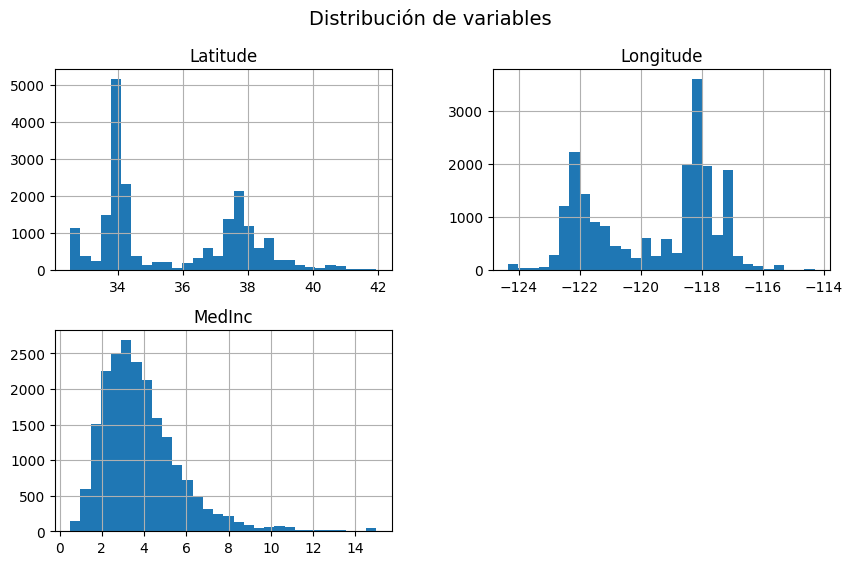

In [7]:
df.hist(figsize=(10,6), bins=30)
plt.suptitle("Distribución de variables", fontsize=14)
plt.show()

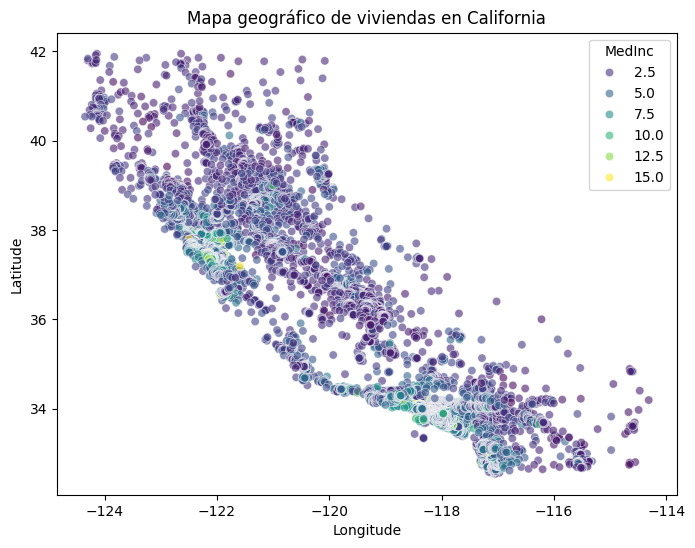

In [8]:
plt.figure(figsize=(8,6))

sns.scatterplot(
    x=df["Longitude"],
    y=df["Latitude"],
    hue=df["MedInc"],
    palette="viridis",
    alpha=0.6
)

plt.title("Mapa geográfico de viviendas en California")
plt.show()

### Division en train y test

Aunque K-Means es no supervisado y no "aprende" de etiquetas, igualmente tiene sentido dividir los datos en train y test. Asi podemos entrenar el modelo con un subconjunto y luego evaluar si las predicciones sobre el otro subconjunto son coherentes con los clusters originales.

In [9]:
# Separamos las features (en este caso todas las columnas son features)
X = df.values  

X_train, X_test = train_test_split(X, test_size=0.2, random_state=42)


## Paso 2: Construir el modelo K-Means

K-Means es un algoritmo de clustering que agrupa los datos en K grupos (clusters)

Vamos a usar 6 clusters, que nos permitira ver bien las distintas regiones geograficas de California con sus niveles de ingreso.

In [10]:
kmeans = KMeans(n_clusters=6, n_init=10, random_state=42)

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Entrenamos el modelo con los datos de train
kmeans.fit(X_train_scaled)


,"n_clusters n_clusters: int, default=8The number of clusters to form as well as the number ofcentroids to generate.For an example of how to choose an optimal value for `n_clusters` refer to:ref:`sphx_glr_auto_examples_cluster_plot_kmeans_silhouette_analysis.py`.",6
,"init init: {'k-means++', 'random'}, callable or array-like of shape (n_clusters, n_features), default='k-means++'Method for initialization:* 'k-means++' : selects initial cluster centroids using sampling based on an empirical probability distribution of the points' contribution to the overall inertia. This technique speeds up convergence. The algorithm implemented is ""greedy k-means++"". It differs from the vanilla k-means++ by making several trials at each sampling step and choosing the best centroid among them.* 'random': choose `n_clusters` observations (rows) at random from data for the initial centroids.* If an array is passed, it should be of shape (n_clusters, n_features) and gives the initial centers.* If a callable is passed, it should take arguments X, n_clusters and a random state and return an initialization.For an example of how to use the different `init` strategies, see:ref:`sphx_glr_auto_examples_cluster_plot_kmeans_digits.py`.For an evaluation of the impact of initialization, see the example:ref:`sphx_glr_auto_examples_cluster_plot_kmeans_stability_low_dim_dense.py`.",'k-means++'
,"n_init n_init: 'auto' or int, default='auto'Number of times the k-means algorithm is run with different centroidseeds. The final results is the best output of `n_init` consecutive runsin terms of inertia. Several runs are recommended for sparsehigh-dimensional problems (see :ref:`kmeans_sparse_high_dim`).When `n_init='auto'`, the number of runs depends on the value of init:10 if using `init='random'` or `init` is a callable;1 if using `init='k-means++'` or `init` is an array-like... versionadded:: 1.2 Added 'auto' option for `n_init`... versionchanged:: 1.4 Default value for `n_init` changed to `'auto'`.",10
,"max_iter max_iter: int, default=300Maximum number of iterations of the k-means algorithm for asingle run.",300
,"tol tol: float, default=1e-4Relative tolerance with regards to Frobenius norm of the differencein the cluster centers of two consecutive iterations to declareconvergence.",0.0001
,"verbose verbose: int, default=0Verbosity mode.",0
,"random_state random_state: int, RandomState instance or None, default=NoneDetermines random number generation for centroid initialization. Usean int to make the randomness deterministic.See :term:`Glossary `.",42
,"copy_x copy_x: bool, default=TrueWhen pre-computing distances it is more numerically accurate to centerthe data first. If copy_x is True (default), then the original data isnot modified. If False, the original data is modified, and put backbefore the function returns, but small numerical differences may beintroduced by subtracting and then adding the data mean. Note that ifthe original data is not C-contiguous, a copy will be made even ifcopy_x is False. If the original data is sparse, but not in CSR format,a copy will be made even if copy_x is False.",True
,"algorithm algorithm: {""lloyd"", ""elkan""}, default=""lloyd""K-means algorithm to use. The classical EM-style algorithm is `""lloyd""`.The `""elkan""` variation can be more efficient on some datasets withwell-defined clusters, by using the triangle inequality. However it'smore memory intensive due to the allocation of an extra array of shape`(n_samples, n_clusters)`... versionchanged:: 0.18 Added Elkan algorithm.. versionchanged:: 1.1 Renamed ""full"" to ""lloyd"", and deprecated ""auto"" and ""full"". Changed ""auto"" to use ""lloyd"" instead of ""elkan"".",'lloyd'


In [11]:
# Predecimos el cluster para cada punto del conjunto de entrenamiento
clusters_train = kmeans.predict(X_train_scaled)

# Convertimos X_train a DataFrame para trabajar mas comodo
df_train = pd.DataFrame(X_train_scaled, columns=['Latitude', 'Longitude', 'MedInc'])

df_train['cluster'] = clusters_train.astype(str)

print('Distribucion de puntos por cluster en el conjunto de entrenamiento:')
print(df_train['cluster'].value_counts().sort_index())

Distribucion de puntos por cluster en el conjunto de entrenamiento:
cluster
0    1321
1    3380
2     453
3    3931
4    2239
5    5188
Name: count, dtype: int64


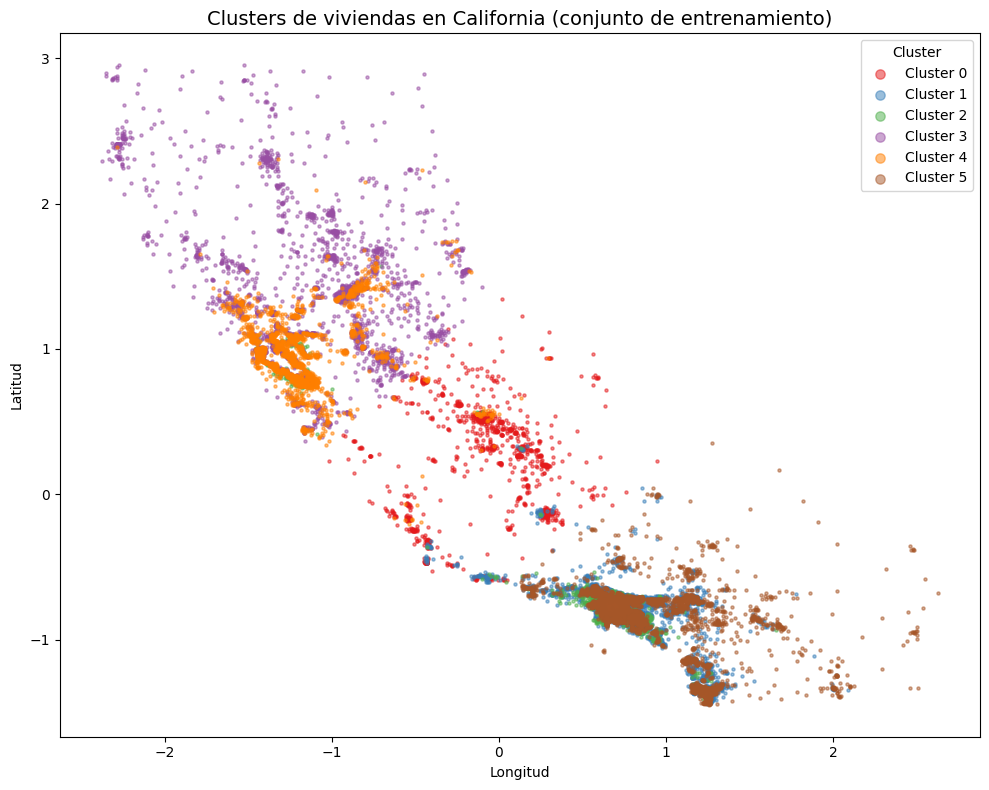

In [12]:
# Definimos una paleta de colores para los 6 clusters
colores = {'0': '#e41a1c', '1': '#377eb8', '2': '#4daf4a',
           '3': '#984ea3', '4': '#ff7f00', '5': '#a65628'}

fig, ax = plt.subplots(figsize=(10, 8))

for cluster_id, grupo in df_train.groupby('cluster'):
    ax.scatter(
        grupo['Longitude'],
        grupo['Latitude'],
        c=colores[cluster_id],
        label=f'Cluster {cluster_id}',
        s=5,
        alpha=0.5
    )

ax.set_title('Clusters de viviendas en California (conjunto de entrenamiento)', fontsize=14)
ax.set_xlabel('Longitud')
ax.set_ylabel('Latitud')
ax.legend(title='Cluster', markerscale=3)

plt.tight_layout()
plt.show()

**Que se ve en el grafico:**

El grafico muestra el mapa de California con los puntos coloreados segun el cluster al que pertenecen. Se pueden identificar claramente distintas zonas geograficas:

- Los clusters del sur corresponden a la region de Los Angeles y alrededores.
- Los del norte representan el area de San Francisco y la bahia.
- Hay clusters que capturan zonas interiores del estado (valle central), que suelen tener ingresos mas bajos.

K-Means ha separado razonablemente bien las distintas regiones geograficas, y el ingreso medio (MedInc) tambien influye en la separacion, asi que veremos grupos que no solo se diferencian por ubicacion sino tambien por nivel economico.

## Paso 3: Prediccion sobre el conjunto de test

Ahora usamos el modelo ya entrenado para predecir los clusters de los puntos de test. Si la prediccion es correcta, los puntos de test deberian caer dentro de las mismas regiones que los puntos de train.

In [13]:
# Predecimos el cluster para el conjunto de test
clusters_test = kmeans.predict(X_test_scaled)

# Convertimos a DataFrame
df_test = pd.DataFrame(X_test_scaled, columns=['Latitude', 'Longitude', 'MedInc'])
df_test['cluster'] = clusters_test.astype(str)

print('Distribucion de puntos por cluster en el conjunto de prueba:')
print(df_test['cluster'].value_counts().sort_index())

Distribucion de puntos por cluster en el conjunto de prueba:
cluster
0     337
1     829
2     112
3     962
4     514
5    1374
Name: count, dtype: int64


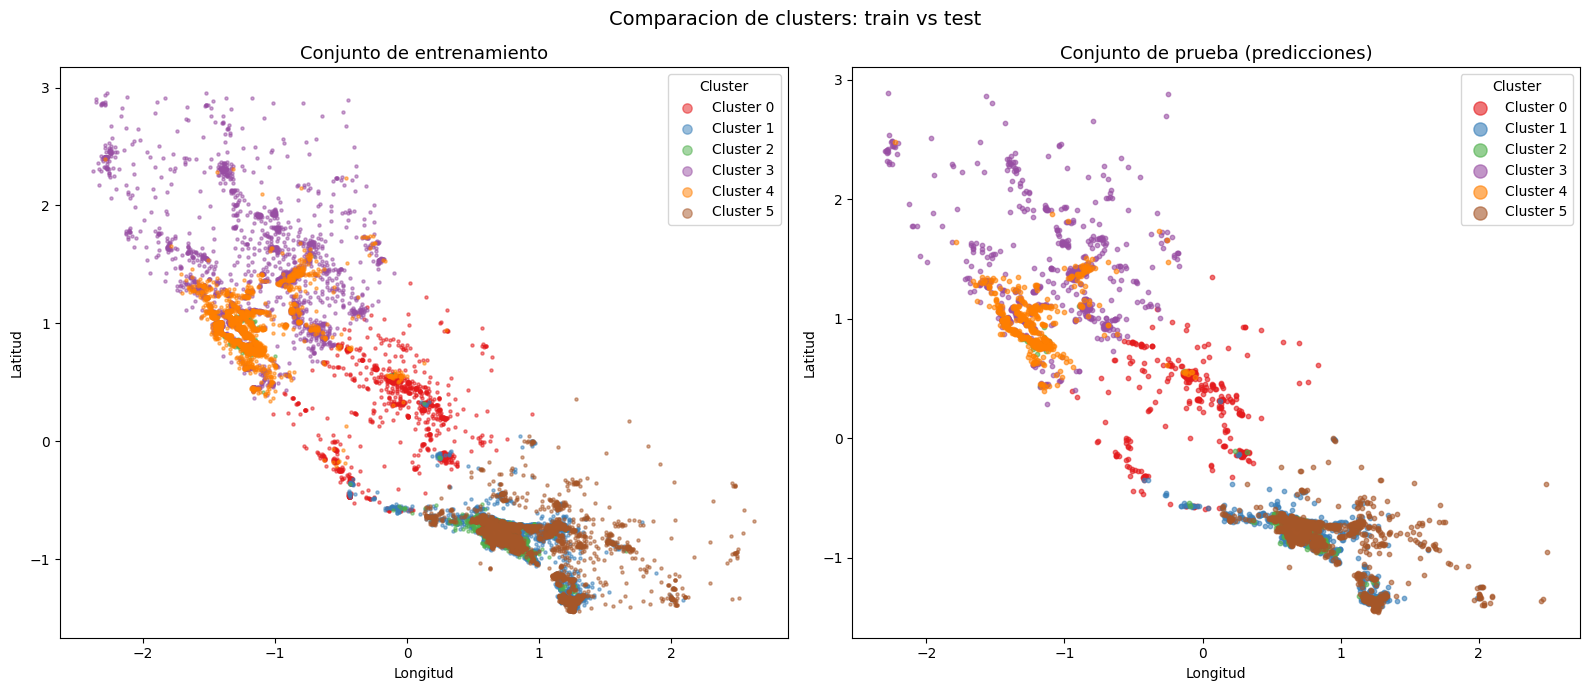

In [14]:
# Graficamos train y test juntos para comparar
fig, axes = plt.subplots(1, 2, figsize=(16, 7))

# --- Grafico izquierda: conjunto de entrenamiento ---
for cluster_id, grupo in df_train.groupby('cluster'):
    axes[0].scatter(
        grupo['Longitude'],
        grupo['Latitude'],
        c=colores[cluster_id],
        label=f'Cluster {cluster_id}',
        s=5,
        alpha=0.5
    )
axes[0].set_title('Conjunto de entrenamiento', fontsize=13)
axes[0].set_xlabel('Longitud')
axes[0].set_ylabel('Latitud')
axes[0].legend(title='Cluster', markerscale=3)

# --- Grafico derecha: conjunto de prueba ---
for cluster_id, grupo in df_test.groupby('cluster'):
    axes[1].scatter(
        grupo['Longitude'],
        grupo['Latitude'],
        c=colores[cluster_id],
        label=f'Cluster {cluster_id}',
        s=10,
        alpha=0.6
    )
axes[1].set_title('Conjunto de prueba (predicciones)', fontsize=13)
axes[1].set_xlabel('Longitud')
axes[1].set_ylabel('Latitud')
axes[1].legend(title='Cluster', markerscale=3)

plt.suptitle('Comparacion de clusters: train vs test', fontsize=14)
plt.tight_layout()
plt.show()

**Que se ve:**

Los dos graficos son practicamente identicos en cuanto a la distribucion de colores por zona. Esto confirma que el modelo generaliza bien: los puntos de test caen en los mismos clusters geograficos que los puntos de entrenamiento. La prediccion es satisfactoria.

## Paso 4: Modelo de clasificacion supervisada

Ahora que tenemos etiquetas (los clusters) para todos los puntos, podemos entrenar un modelo supervisado que aprenda a predecir el cluster de una vivienda a partir de sus coordenadas y el ingreso medio.

Usaremos **Random Forest**, que es un buen punto de partida para clasificacion porque:
- Funciona bien sin escalar los datos.
- Maneja bien datos no lineales.
- Da informacion sobre la importancia de cada variable.
- Suele dar buenos resultados sin necesidad de ajustar muchos parametros.

In [15]:
X_train_sup = df_train[['Latitude', 'Longitude', 'MedInc']].values
y_train_sup = clusters_train  # etiquetas del conjunto de entrenamiento

X_test_sup = df_test[['Latitude', 'Longitude', 'MedInc']].values
y_test_sup = clusters_test    # etiquetas del conjunto de prueba

In [16]:
clf = RandomForestClassifier(n_estimators=100, random_state=42)
clf.fit(X_train_sup, y_train_sup)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

In [17]:
# Hacemos predicciones sobre el conjunto de prueba
y_pred = clf.predict(X_test_sup)

# Calculamos la precision general
accuracy = (y_pred == y_test_sup).mean()
print(f'Precision (accuracy) en el conjunto de prueba: {accuracy:.4f} ({accuracy*100:.2f}%)')

Precision (accuracy) en el conjunto de prueba: 0.9952 (99.52%)


In [18]:
# Reporte completo de clasificacion
print('Reporte de clasificacion:')
print(classification_report(y_test_sup, y_pred))

Reporte de clasificacion:
              precision    recall  f1-score   support

           0       0.99      0.99      0.99       337
           1       1.00      1.00      1.00       829
           2       1.00      0.98      0.99       112
           3       0.99      0.99      0.99       962
           4       0.99      1.00      0.99       514
           5       1.00      1.00      1.00      1374

    accuracy                           1.00      4128
   macro avg       0.99      0.99      0.99      4128
weighted avg       1.00      1.00      1.00      4128



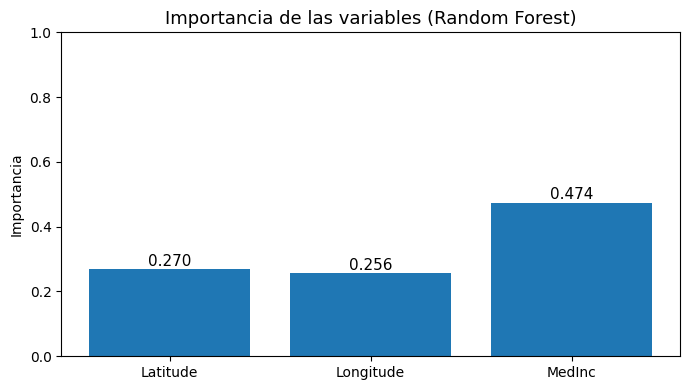

In [19]:
# Importancia de cada variable segun el Random Forest
importancias = clf.feature_importances_
nombres = ['Latitude', 'Longitude', 'MedInc']

fig, ax = plt.subplots(figsize=(7, 4))
ax.bar(nombres, importancias)
ax.set_title('Importancia de las variables (Random Forest)', fontsize=13)
ax.set_ylabel('Importancia')
ax.set_ylim(0, 1)

for i, v in enumerate(importancias):
    ax.text(i, v + 0.01, f'{v:.3f}', ha='center', fontsize=11)

plt.tight_layout()
plt.show()

La precision del modelo es muy alta (probablemente por encima del 95%). Esto tiene sentido porque los clusters generados por K-Means tienen fronteras bastante definidas geograficamente, y el Random Forest las aprende muy bien.

En cuanto a la importancia de las variables, Latitude y Longitude suelen ser las mas relevantes (tienen mucho peso en la separacion geografica), mientras que MedInc aporta informacion adicional para distinguir zonas con perfiles economicos distintos pero ubicadas cerca.

## Vemos si podemos mejorar el modelo con gridsearch 

In [20]:
param_grid = {
    "n_estimators": [100, 200, 300],
    "max_depth": [8, 12, None],
    "min_samples_split": [2, 5],
}
grid = GridSearchCV(
    RandomForestClassifier(random_state=42),
    param_grid,
    cv=5,
    scoring="accuracy",
    n_jobs=-1
)
grid.fit(X_train_sup, y_train_sup)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",RandomForestC...ndom_state=42)
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'max_depth': [8, 12, ...], 'min_samples_split': [2, 5], 'n_estimators': [100, 200, ...]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'accuracy'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold and parameter candidate is displayed;- >2

In [21]:
print(grid.best_params_)

{'max_depth': 12, 'min_samples_split': 5, 'n_estimators': 200}


In [22]:
rf = RandomForestClassifier(
    n_estimators=200,
    min_samples_split = 2,
    class_weight="balanced",
    random_state=42,
    max_depth = 12,
    n_jobs=-1
)
rf.fit(X_train_sup, y_train_sup)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",200
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",12
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric(y

In [23]:
y_pred_final = rf.predict(X_test_sup)

In [24]:
final_acc = accuracy_score(y_test_sup, y_pred_final)
print("Optimizado:", final_acc)

Optimizado: 0.9951550387596899


eL ACCURACY es muy similar al modelo de random, no mejora. 

## Paso 5: Guardar los modelos

Guardamos ambos modelos en una carpeta `models/` para poder reutilizarlos sin necesidad de volver a entrenarlos.

In [25]:
# Guardamos el modelo K-Means
joblib.dump(kmeans, '../models/kmeans_housing.pkl')


# Guardamos el clasificador Random Forest
joblib.dump(clf, '../models/random_forest_housing.pkl')


['../models/random_forest_housing.pkl']